# Mental Health Classification

## Set Up

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset mental_health_risk_dataset

In [6]:
df = pd.read_csv('/Users/user/my_project/Mental-Health-Risk-Prediction/data/mental_health_risk_dataset.csv')
df

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,36,Female,Single,Bachelor,Unemployed,3.3,8.4,4.6,4,3,...,1,2,5,1,0,0,1,0,0,0
24996,49,Female,Divorced,Master,Student,4.7,6.6,2.1,6,6,...,2,8,7,1,1,0,0,0,1,1
24997,35,Female,Married,PhD,Self-Employed,4.0,12.8,11.3,4,10,...,7,3,3,4,1,0,1,0,1,2
24998,44,Male,Divorced,High School,Student,5.1,2.0,3.0,5,4,...,7,7,8,1,0,1,1,0,1,0


## [1]Data Cleaning

### Gender

In [7]:
df['gender'].unique()

<StringArray>
['Other', 'Male', 'Female']
Length: 3, dtype: str

### Marital_status

In [8]:
df['marital_status'].unique()

<StringArray>
['Single', 'Divorced', 'Married']
Length: 3, dtype: str

### Education_level

In [9]:
df['education_level'].unique()

<StringArray>
['Bachelor', 'High School', 'Master', 'PhD']
Length: 4, dtype: str

### Employment_status

In [10]:
df['employment_status'].unique()

<StringArray>
['Unemployed', 'Student', 'Employed', 'Self-Employed']
Length: 4, dtype: str

### Column

In [11]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level',
       'employment_status', 'sleep_hours', 'physical_activity_hours_per_week',
       'screen_time_hours_per_day', 'social_support_score',
       'work_stress_level', 'academic_pressure_level',
       'job_satisfaction_score', 'financial_stress_level',
       'working_hours_per_week', 'anxiety_score', 'depression_score',
       'stress_level', 'mood_swings_frequency',
       'concentration_difficulty_level', 'panic_attack_history',
       'family_history_mental_illness', 'previous_mental_health_diagnosis',
       'therapy_history', 'substance_use', 'mental_health_risk'],
      dtype='str')

### Checking for Missing Values

In [12]:
df.isna().sum()

age                                 0
gender                              0
marital_status                      0
education_level                     0
employment_status                   0
sleep_hours                         0
physical_activity_hours_per_week    0
screen_time_hours_per_day           0
social_support_score                0
work_stress_level                   0
academic_pressure_level             0
job_satisfaction_score              0
financial_stress_level              0
working_hours_per_week              0
anxiety_score                       0
depression_score                    0
stress_level                        0
mood_swings_frequency               0
concentration_difficulty_level      0
panic_attack_history                0
family_history_mental_illness       0
previous_mental_health_diagnosis    0
therapy_history                     0
substance_use                       0
mental_health_risk                  0
dtype: int64

### REMOVE bad columns

In [76]:
drop_cols = [
    "social_support_score",
    "work_stress_level",
    "academic_pressure_level",
    "anxiety_score",
    "depression_score",
    "stress_level",
    "mood_swings_frequency",
    "concentration_difficulty_level",
    "panic_attack_history",
    "family_history_mental_illness",
    "previous_mental_health_diagnosis",
    "therapy_history",
    "substance_use",
    "mental_health_risk"
]

X = df.drop(drop_cols, axis=1)
y = df["mental_health_risk"]

## [2] Visualization

### ①Age

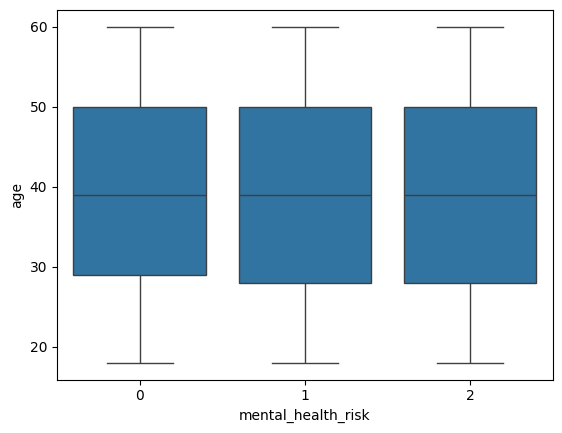

In [77]:
sns.boxplot(x="mental_health_risk", y="age", data=df)
plt.show()

### ②Gender

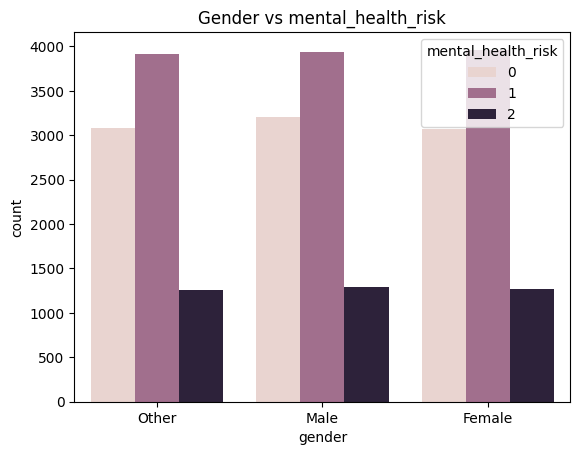

In [78]:
sns.countplot(x="gender",hue="mental_health_risk", data=df)
plt.title("Gender vs mental_health_risk")
plt.show()

### ③Marital Status

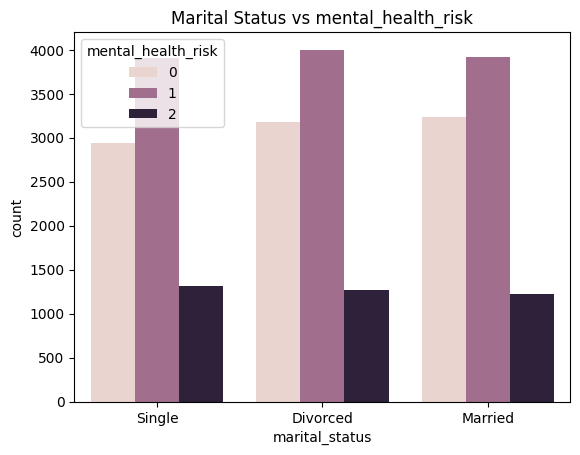

In [79]:
sns.countplot(x="marital_status",hue="mental_health_risk", data=df)
plt.title("Marital Status vs mental_health_risk")
plt.show()

### ④Education Level

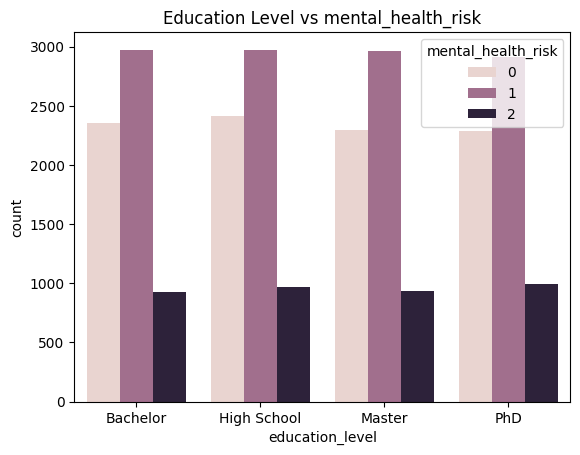

In [80]:
sns.countplot(x="education_level",hue="mental_health_risk", data=df)
plt.title("Education Level vs mental_health_risk")
plt.show()

### ⑤ Sleep Hours

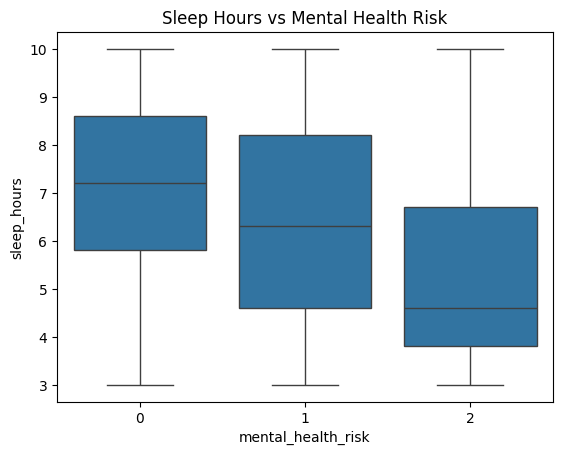

In [81]:
sns.boxplot(x="mental_health_risk", y="sleep_hours", data=df)
plt.title("Sleep Hours vs Mental Health Risk")
plt.show()

## [3] Model Selection

### Set Up

In [89]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import joblib

In [90]:
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)


### ① Logistic Regression

In [91]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

y_predict_lr = lr.predict(X_test)


### ②Random Forest

In [92]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_predict_rf = rf.predict(X_test)

### ③ SVM

In [93]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

### Accuracy Score

In [94]:
print("Logistic Regression:", accuracy_score(y_test, y_predict_lr))
print("Random Forest:", accuracy_score(y_test, y_predict_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Logistic Regression: 0.5078
Random Forest: 0.528
SVM: 0.5246


Since the Random Forest has the highest accuracy score, I will use random forest for my model.

In [96]:
joblib.dump({
    "model": rf,
    "features": X.columns
}, "mental_health_model.pkl")

['mental_health_model.pkl']

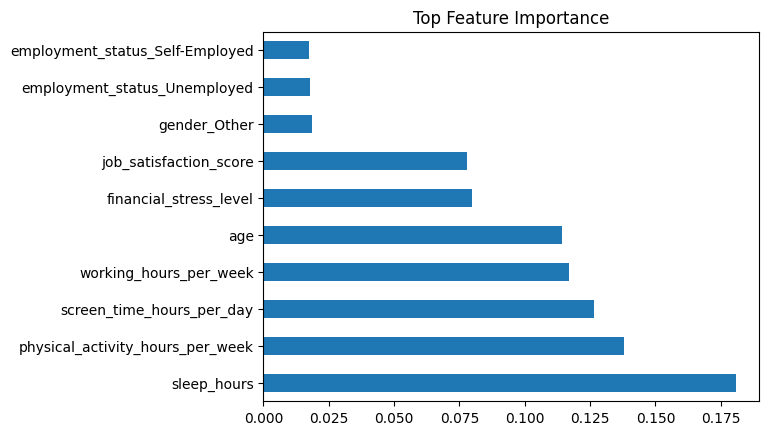

In [97]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top Feature Importance")
plt.show()